# NB3 — Key Feature and Model Comparisons


This is an English, curated retrospective of the first bootcamp project. It follows the original presentation and retains the experiments needed to understand the selected model. It does not include the later Claude Code/GitHub upgrade.

**Two kinds of evidence:** snapshot statistics are computed from the supplied CSV; historical model metrics are transcribed from the original notebooks' stored outputs and explicitly labeled. The models have not been retrained for this edition. Set the relevant run flag to opt into an adapted historical rerun; scores may differ because the original `df_keyword.csv`, environment, and all intermediate states are unavailable. The supplied `CleanedDataset.csv` is used as a documented substitute, not asserted to be byte-identical to that intermediate file.

Cells carry original filenames and zero-based cell references in metadata. No API call or model download runs by default. The original evaluation limitations are noted without silently replacing the first project with an improved pipeline.


In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

# Place the supplied CSV files in data/, or set RASFF_DATA_DIR.
DATA_DIR = Path(os.environ.get("RASFF_DATA_DIR", "data"))
clean_path = DATA_DIR / "CleanedDataset.csv"
if not clean_path.exists():
    raise FileNotFoundError("Place the original CleanedDataset.csv in data/ or set RASFF_DATA_DIR.")
df = pd.read_csv(clean_path).reset_index(drop=True)
RUN_EXPERIMENTS = False
RUN_LLM_SAMPLE = False
SAVE_ARTIFACTS = False
print(f"Provided clean snapshot: {df.shape[0]:,} rows x {df.shape[1]} columns")


Provided clean snapshot: 27,397 rows x 23 columns


## 1. Time-split feature ablation: which fields helped?
The original binary feature experiment sorted records by date, chose the row at `int(n * 0.8)` as the cutoff, and assigned dates at/before the cutoff to training and later dates to testing. The retained combinations explain the presentation's feature-selection curve.

The same XGBoost settings were used: 1,000 trees, depth 10, learning rate 0.03, minimum child weight 10, gamma 0.2, subsample 1.0, column sampling 0.6. Feature vocabulary for one-hot/multi-hot was built across the snapshot in that historical code.


In [2]:
df["date"] = pd.to_datetime(df["date"])
dated = df.sort_values("date")
cutoff = dated.iloc[int(len(dated)*0.8)]["date"]
train_df = dated[dated["date"] <= cutoff].copy()
test_df = dated[dated["date"] > cutoff].copy()
print("Cutoff:", cutoff)
print("Training / testing:", len(train_df), len(test_df))
recorded_ablation = pd.DataFrame([
    ("subject", .7521445519255339, 21),
    ("subject + category", .7505019164081037, 19),
    ("subject + category + Hazard_Type", .7578025187077934, 17),
    ("subject + category + Hazard_Type + origin", .7539697025004563, 14),
    ("subject + category + Hazard_Type + origin + classification", .8256981200949078, 30),
    ("subject + category + Hazard_Type + classification", .8244205146924621, 33),
    ("subject + category + Hazard_Type + classification + year + month", .8309910567621829, 37),
], columns=["Actual input fields", "Recorded accuracy", "Original cell"])
display(recorded_ablation)


Cutoff: 2024-10-17 10:37:10
Training / testing: 21918 5479


,Actual input fields,Recorded accuracy,Original cell
0,subject,0.752145,21
1,subject + category,0.750502,19
2,subject + category + Hazard_Type,0.757803,17
3,subject + category + Hazard_Type + origin,0.753970,14
4,subject + category + Hazard_Type + origin + cl...,0.825698,30
5,subject + category + Hazard_Type + classification,0.824421,33
6,subject + category + Hazard_Type + classificat...,0.830991,37


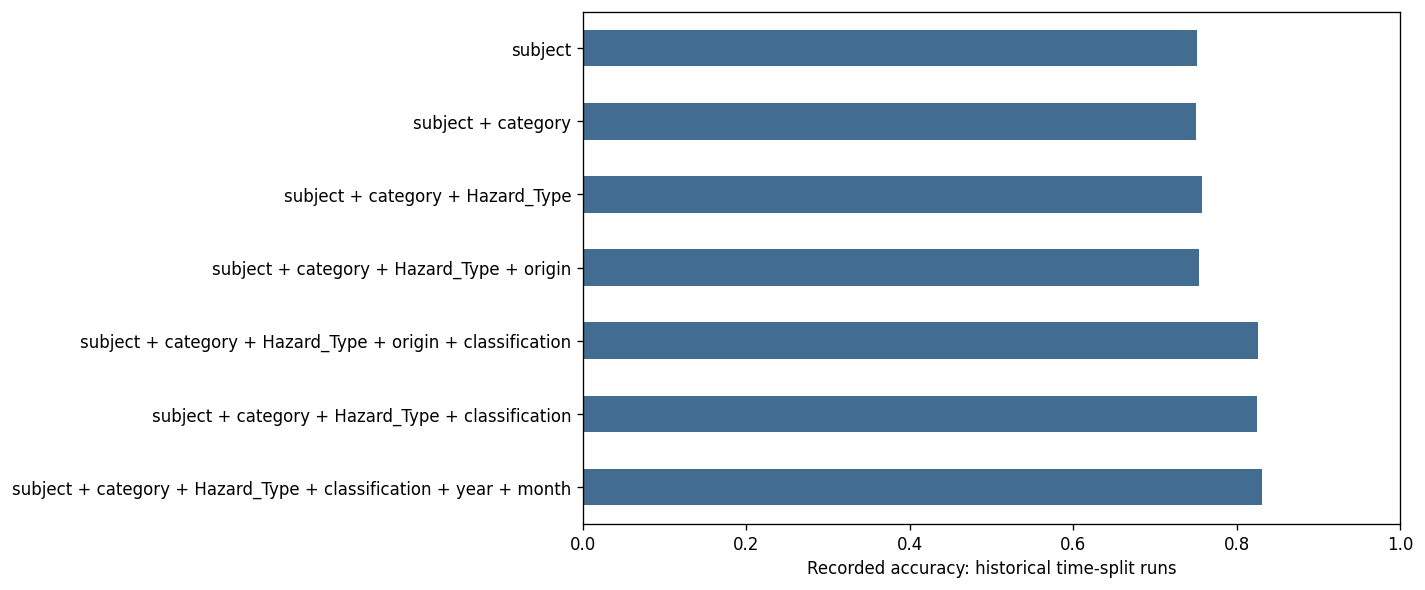

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
recorded_ablation.iloc[::-1].plot.barh(x="Actual input fields", y="Recorded accuracy", ax=ax,
                                      color="#426d91", legend=False)
ax.set(xlim=(0, 1), xlabel="Recorded accuracy: historical time-split runs", ylabel="")
fig.tight_layout()
plt.show()


Adding category alone did not improve subject-only performance; adding origin also did not consistently help. Notification classification was associated with the largest increase in this table. Whether it would be available at the intended prediction time is a separate question reserved for the later review. This table describes the first experiments, not an operational feature-availability decision.

Field names replace the presentation's inconsistent “5 features” / “7 features” labels. The last two relevant combinations actually contain four and six raw input columns. Under-sampling runs with mismatched train/test feature assembly were excluded from the comparison.


### Optional adapted rerun of the retained ablation
This keeps the historical split, representation choices, and model parameters. It requires model dependencies and downloads, and trains seven large models. Keep the flag off for normal reading.


In [4]:
if RUN_EXPERIMENTS:
    import re
    from sentence_transformers import SentenceTransformer
    from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
    from sklearn.metrics import accuracy_score
    from xgboost import XGBClassifier

    def clean_text(text):
        text = re.sub(r"/+", " ", str(text))
        text = re.sub(r"(\d)([A-Za-z])", r"\1 \2", text)
        return re.sub(r"\s+", " ", text).strip()

    work = dated.copy()
    work["risk_binary"] = work["risk_decision"].eq("serious").astype(int)
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    blocks = {}
    for field in ["subject", "category"]:
        values = embedder.encode(work[field].map(clean_text).tolist(), show_progress_bar=True)
        blocks[field] = pd.DataFrame(values, index=work.index,
                                     columns=[f"{field}_emb_{i}" for i in range(values.shape[1])])
    for field in ["Hazard_Type", "classification"]:
        blocks[field] = pd.get_dummies(work[field], prefix=field)
    origins = work["origin"].fillna("").str.split(r"[,/]+", regex=True).map(
        lambda parts: [part.strip() for part in parts if part.strip()])
    mlb = MultiLabelBinarizer()
    blocks["origin"] = pd.DataFrame(mlb.fit_transform(origins), index=work.index,
                                    columns=[f"origin_{i}" for i in range(len(mlb.classes_))])
    scaler = MinMaxScaler()
    calendar = pd.DataFrame(index=work.index, columns=["year", "month"], dtype=float)
    calendar.loc[train_df.index] = scaler.fit_transform(work.loc[train_df.index, ["year", "month"]])
    calendar.loc[test_df.index] = scaler.transform(work.loc[test_df.index, ["year", "month"]])
    blocks["year"] = calendar[["year"]]
    blocks["month"] = calendar[["month"]]
    rerun_rows = []
    for combination in recorded_ablation["Actual input fields"]:
        fields = combination.split(" + ")
        X = pd.concat([blocks[field] for field in fields], axis=1)
        X.columns = [f"feature_{i}" for i in range(X.shape[1])]
        clf = XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                            learning_rate=.03, max_depth=10, subsample=1.0, colsample_bytree=.6,
                            n_estimators=1000, min_child_weight=10, gamma=.2,
                            tree_method="hist", random_state=42)
        clf.fit(X.loc[train_df.index], work.loc[train_df.index, "risk_binary"])
        pred = clf.predict(X.loc[test_df.index])
        rerun_rows.append({"Input fields": combination,
                           "Rerun accuracy": accuracy_score(work.loc[test_df.index, "risk_binary"], pred)})
    display(pd.DataFrame(rerun_rows))
else:
    print("Optional historical experiment skipped.")


Optional historical experiment skipped.


## 2. Historical algorithm comparison: three-class task
This was a different branch: paraphrase-MiniLM-L6-v2 embeddings of subject and category, Hazard_Type one-hot, and origin multi-hot; stratified random 80/20 split, seed 42. Logistic Regression used a train-fitted StandardScaler; the tree models used the unscaled matrix. Do not merge this table with the time-split ablation.


In [5]:
recorded_models = pd.DataFrame([
    ("Logistic Regression", .6889, .6332),
    ("Random Forest", .7318, .6769),
    ("XGBoost", .7285, .6803),
    ("LightGBM", .7361, .6895),
], columns=["Model", "Recorded accuracy", "Recorded macro F1"])
display(recorded_models)


,Model,Recorded accuracy,Recorded macro F1
0,Logistic Regression,0.6889,0.6332
1,Random Forest,0.7318,0.6769
2,XGBoost,0.7285,0.6803
3,LightGBM,0.7361,0.6895


### Optional adapted rerun of the four algorithms
The code retains the original model definitions and representation choices. New results remain distinct from the stored historical outputs.


In [6]:
if RUN_EXPERIMENTS:
    import re
    from sentence_transformers import SentenceTransformer
    from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, f1_score, classification_report
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    work = df.copy()
    def clean_text(text):
        text = re.sub(r"/+", " ", str(text))
        text = re.sub(r"(\d)([A-Za-z])", r"\1 \2", text)
        return re.sub(r"\s+", " ", text).strip()
    work["subject_clean"] = work["subject"].map(clean_text)
    work["category_clean"] = work["category"].map(clean_text)
    three_map = {"no risk":0,"not serious":0,"potential risk":1,"undecided":1,"potentially serious":1,"serious":2}
    work["risk_decision_3class"] = work["risk_decision"].map(three_map)
    # ============================================================
    # 4. ParaBERT Embeddings (only subject + category)
    # ============================================================

    model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L6-v2")

    print("Encoding SUBJECT…")
    subject_embeddings = model.encode(work["subject_clean"].tolist(), show_progress_bar=True)

    print("Encoding CATEGORY…")
    category_embeddings = model.encode(work["category_clean"].tolist(), show_progress_bar=True)

    # Combine both embeddings
    X = np.hstack([subject_embeddings, category_embeddings])

    # Encode target
    y = work["risk_decision_3class"]
    #Hazard type one-hot
    hazard_ohe = pd.get_dummies(work["Hazard_Type"], prefix="hazard")
    #Origin multi-hot
    # Replace NaN with empty string
    work["origin"] = work["origin"].fillna("")

    # Split by delimiter if multiple origins
    work["origin_list"] = work["origin"].str.split(r"[,/]+")
    all_origins = sorted(set([o.strip() for sublist in work["origin_list"] for o in sublist if o.strip()]))

    for o in all_origins:
        work[f"origin_{o}"] = work["origin_list"].apply(lambda x: 1 if o in [i.strip() for i in x] else 0)

    origin_features = work[[f"origin_{o}" for o in all_origins]]
    X = np.hstack([subject_embeddings, category_embeddings, hazard_ohe.values, origin_features.values])
    y = work["risk_decision_3class"]

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # ---------------------------------------------------------
    # 5. DEFINE BASELINE MODELS
    # ---------------------------------------------------------
    models = {
        "Logistic Regression": LogisticRegression(max_iter=5000),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
        "XGBoost": XGBClassifier(tree_method="hist", eval_metric="mlogloss", use_label_encoder=False, random_state=42),
        "LightGBM": LGBMClassifier(n_estimators=300, random_state=42),
    }


    # ---------------------------------------------------------
    # 6. TRAIN, EVALUATE, COLLECT RESULTS
    # ---------------------------------------------------------
    results = {}

    for name, clf in models.items():
        print(f"\nTraining {name}...")

        # Use scaled data only for Logistic Regression
        if name == "Logistic Regression":
            clf.fit(X_train_scaled, y_train)
            preds = clf.predict(X_test_scaled)
        else:
            clf.fit(X_train, y_train)
            preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro")
        results[name] = {"accuracy": acc, "f1_macro": f1}

        print(f"Accuracy: {acc:.4f} | F1-macro: {f1:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, preds))
else:
    print("Optional historical experiment skipped.")


Optional historical experiment skipped.


## 3. Move to a mixed representation for the binary task
The later branch combined subject/category embeddings, target encoding of notifying country/origin/simplified_hazard, and one-hot encoding of type/classification. Stored output gave 780 numerical columns. XGBoost and LightGBM were both retained for the next stage; neither was uniformly best across every experiment.

These later runs used stratified random 70/30 splitting. They are not a continuation of the same time-held-out experiment. Historical target encoding was fitted using all labels before splitting: the reported results need a later leakage review and cannot establish independent future performance.


In [7]:
recorded_mixed = pd.DataFrame([
    ("XGBoost", .8871, 5), ("LightGBM", .8873, 7)
], columns=["Model", "Recorded accuracy (rounded)", "Original cell"])
display(recorded_mixed)


,Model,Recorded accuracy (rounded),Original cell
0,XGBoost,0.8871,5
1,LightGBM,0.8873,7


## Handoff to NB4
The remaining question was how to choose a presentable final candidate while looking at train/test gaps and feature complexity. The selected candidate is traced to its exact original cells rather than inferred from a manually drawn summary chart.
